# Primjena metoda mašinskog učenja za identifikaciju faktora rizika i klasifikaciju abnormalnosti krvnog pritiska

#Ucitavanje biblioteka

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
!gdown 1mig6WygA9fCZlKSRf0FQFLqXc241-qVd

Downloading...
From (original): https://drive.google.com/uc?id=1mig6WygA9fCZlKSRf0FQFLqXc241-qVd
From (redirected): https://drive.google.com/uc?id=1mig6WygA9fCZlKSRf0FQFLqXc241-qVd&confirm=t&uuid=eb03fc0d-4865-460e-9889-589a36bfa8ed
To: /content/city_temperature.csv
100% 141M/141M [00:02<00:00, 56.9MB/s]


#Analiza baze podataka

In [3]:
# učitavanje u dataframe format
df = pd.read_csv('/content/data.csv')

# format podataka
print("shape: \n", df.shape)
print("\n types:\n", df.dtypes, "\n")
df.head()

shape: 
 (2000, 15)

 types:
 Patient_Number                     int64
Blood_Pressure_Abnormality         int64
Level_of_Hemoglobin              float64
Genetic_Pedigree_Coefficient     float64
Age                                int64
BMI                                int64
Sex                                int64
Pregnancy                        float64
Smoking                            int64
Physical_activity                  int64
salt_content_in_the_diet           int64
alcohol_consumption_per_day      float64
Level_of_Stress                    int64
Chronic_kidney_disease             int64
Adrenal_and_thyroid_disorders      int64
dtype: object 



,Patient_Number,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Pregnancy,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,1,11.28,0.90,34,23,1,1.0,0,45961,48071,NaN,2,1,1
1,2,0,9.75,0.23,54,33,1,NaN,0,26106,25333,205.0,3,0,0
2,3,1,10.79,0.91,70,49,0,NaN,0,9995,29465,67.0,2,1,0
3,4,0,11.00,0.43,71,50,0,NaN,0,10635,7439,242.0,1,1,0
4,5,1,14.17,0.83,52,19,0,NaN,0,15619,49644,397.0,2,0,0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Klasifikacioni problem sa 2 klase

In [4]:
print(pd.unique(df[ 'Blood_Pressure_Abnormality' ]))

[1 0]


##Broj uzoraka i obiljezja

In [5]:
df.shape

(2000, 15)

Procentualni udio uzoraka u svakoj klasi

In [6]:
class_percentage = df['Blood_Pressure_Abnormality'].value_counts(normalize=True) * 100

print("Procentualni udeo uzoraka u svakoj klasi:")
print(class_percentage)

Procentualni udeo uzoraka u svakoj klasi:
Blood_Pressure_Abnormality
0    50.65
1    49.35
Name: proportion, dtype: float64


##Nedostajuce vrijednosti

In [7]:
NANs = df.isnull().sum()
print(NANs)
udeo = df.isnull().sum()/len(df)*100
print("\n Procenat NaN: \n", udeo)

Patient_Number                      0
Blood_Pressure_Abnormality          0
Level_of_Hemoglobin                 0
Genetic_Pedigree_Coefficient       92
Age                                 0
BMI                                 0
Sex                                 0
Pregnancy                        1558
Smoking                             0
Physical_activity                   0
salt_content_in_the_diet            0
alcohol_consumption_per_day       242
Level_of_Stress                     0
Chronic_kidney_disease              0
Adrenal_and_thyroid_disorders       0
dtype: int64

 Procenat NaN: 
 Patient_Number                    0.0
Blood_Pressure_Abnormality        0.0
Level_of_Hemoglobin               0.0
Genetic_Pedigree_Coefficient      4.6
Age                               0.0
BMI                               0.0
Sex                               0.0
Pregnancy                        77.9
Smoking                           0.0
Physical_activity                 0.0
salt_content_in_the

##Nevalidne vrijednosti

In [8]:
print(df.describe())

       Patient_Number  Blood_Pressure_Abnormality  Level_of_Hemoglobin  \
count     2000.000000                 2000.000000          2000.000000   
mean      1000.500000                    0.493500            11.710035   
std        577.494589                    0.500083             2.186701   
min          1.000000                    0.000000             8.100000   
25%        500.750000                    0.000000            10.147500   
50%       1000.500000                    0.000000            11.330000   
75%       1500.250000                    1.000000            12.945000   
max       2000.000000                    1.000000            17.560000   

       Genetic_Pedigree_Coefficient          Age          BMI          Sex  \
count                   1908.000000  2000.000000  2000.000000  2000.000000   
mean                       0.494817    46.558500    30.081500     0.496000   
std                        0.291736    17.107832    11.761208     0.500109   
min                  

#Obrada baze podataka

##Rjesavanje nedostajucih vrijednosti

In [9]:
print(pd.unique(df[ 'Pregnancy' ]))

[ 1. nan  0.]


Izbacivanje obiljezja "Pregnancy"

In [10]:
df.drop(['Pregnancy'], inplace=True, axis = 1)

Izbacivanje obiljezja "Patient number"

In [11]:
df.drop(['Patient_Number'], inplace=True, axis = 1)

In [12]:
df.head()

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,2,1,1
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,3,0,0
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,2,1,0
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,1,1,0
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,2,0,0


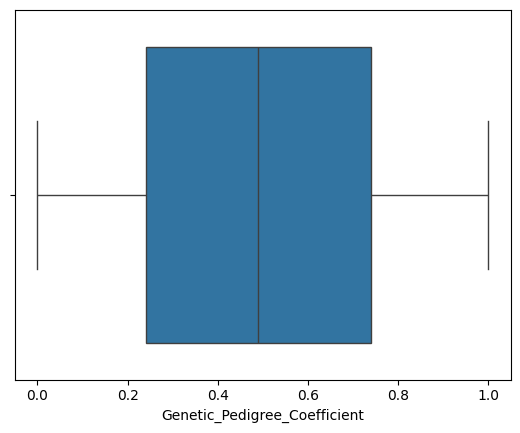

In [13]:
sns.boxplot(x=df['Genetic_Pedigree_Coefficient'])
plt.show()

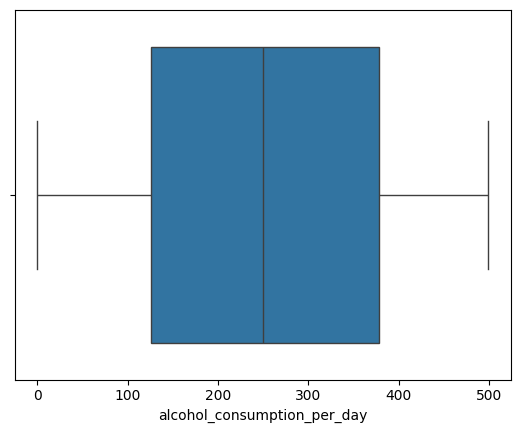

In [14]:
sns.boxplot(x=df['alcohol_consumption_per_day'])
plt.show()

Dopuna nedostajucih vrijednosti kod obiljezja 'Genetic_Pedigree_Coefficient' i 'alcohol_consumption_per_day'

In [14]:
df.fillna(df['Genetic_Pedigree_Coefficient'].mean(), inplace =True)

In [15]:
df.fillna(df['alcohol_consumption_per_day'].median(), inplace =True)

Provjera nedostajucih vrijednosti nakon izbacivanja odgovarajucih

In [16]:
NANs = df.isnull().sum()
print(NANs)
udeo = df.isnull().sum()/len(df)*100
print("\n Procenat NaN: \n", udeo)

Blood_Pressure_Abnormality       0
Level_of_Hemoglobin              0
Genetic_Pedigree_Coefficient     0
Age                              0
BMI                              0
Sex                              0
Smoking                          0
Physical_activity                0
salt_content_in_the_diet         0
alcohol_consumption_per_day      0
Level_of_Stress                  0
Chronic_kidney_disease           0
Adrenal_and_thyroid_disorders    0
dtype: int64

 Procenat NaN: 
 Blood_Pressure_Abnormality       0.0
Level_of_Hemoglobin              0.0
Genetic_Pedigree_Coefficient     0.0
Age                              0.0
BMI                              0.0
Sex                              0.0
Smoking                          0.0
Physical_activity                0.0
salt_content_in_the_diet         0.0
alcohol_consumption_per_day      0.0
Level_of_Stress                  0.0
Chronic_kidney_disease           0.0
Adrenal_and_thyroid_disorders    0.0
dtype: float64


In [17]:
df.describe()

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000
mean,0.493500,11.710035,0.494817,46.558500,30.081500,0.496000,0.509500,25254.424500,24926.097000,220.696373,2.012500,0.5050,0.443500
std,0.500083,2.186701,0.284944,17.107832,11.761208,0.500109,0.500035,14015.439623,14211.692586,157.530312,0.823822,0.5001,0.496922
min,0.000000,8.100000,0.000000,18.000000,10.000000,0.000000,0.000000,628.000000,22.000000,0.000000,1.000000,0.0000,0.000000
25%,0.000000,10.147500,0.250000,32.000000,20.000000,0.000000,0.000000,13605.750000,13151.750000,79.000000,1.000000,0.0000,0.000000
50%,0.000000,11.330000,0.494817,46.000000,30.000000,0.000000,1.000000,25353.000000,25046.500000,212.500000,2.000000,1.0000,0.000000
75%,1.000000,12.945000,0.730000,62.000000,40.000000,1.000000,1.000000,37382.250000,36839.750000,360.250000,3.000000,1.0000,1.000000
max,1.000000,17.560000,1.000000,75.000000,50.000000,1.000000,1.000000,49980.000000,49976.000000,499.000000,3.000000,1.0000,1.000000


Broj uzoraka i obiljezja nakon izbacivanja

In [18]:
df.shape

(2000, 13)

Outlayer-i se javljaju kod nivoa hemoglobina

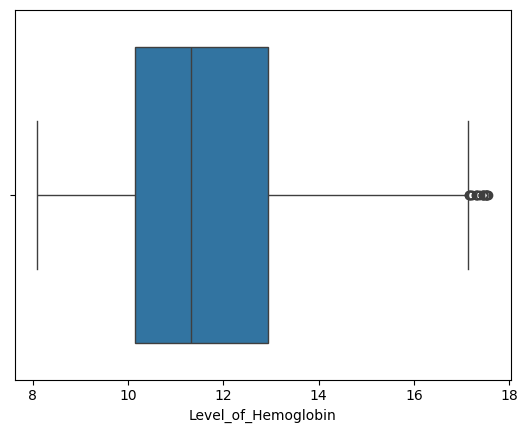

In [20]:
sns.boxplot(x=df['Level_of_Hemoglobin'])
plt.show()

##Matrica korelacija za sva obiljezja

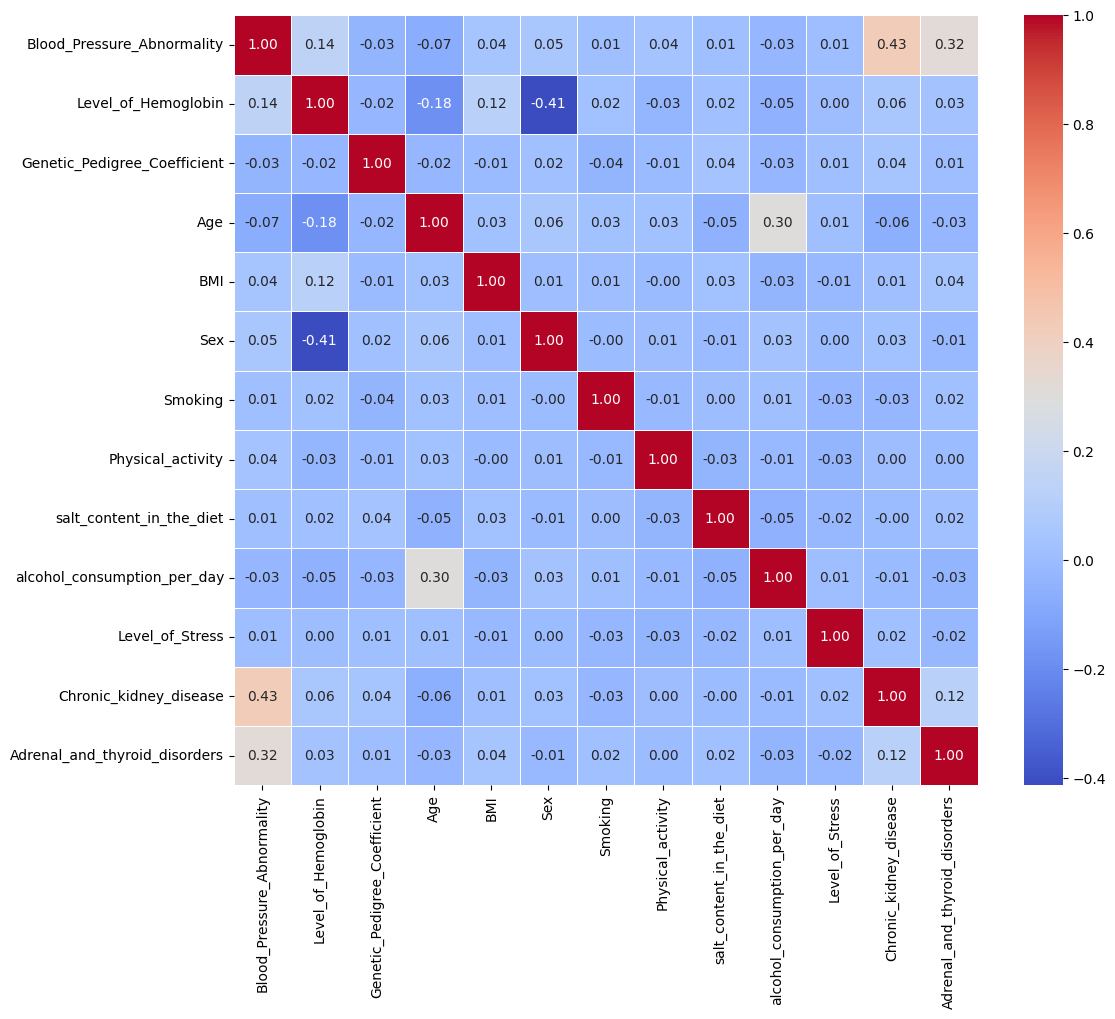

In [21]:
# Matrica korelacije za sve obilježja
matrica_korelacije = df.corr()

# Prikazivanje heatmap-a matrice korelacije
plt.figure(figsize=(12, 10))
sns.heatmap(matrica_korelacije, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()


##Numericka obiljezja

(array([1.64626177e-05, 2.10927289e-05, 2.16071857e-05, 1.85204449e-05,
        1.95493585e-05, 1.64626177e-05, 2.26360993e-05, 2.10927289e-05,
        2.16071857e-05, 2.05782721e-05, 2.00638153e-05, 1.54337041e-05,
        2.16071857e-05, 1.95493585e-05, 2.36650129e-05, 2.26360993e-05,
        1.80059881e-05, 1.49192473e-05, 2.41794697e-05, 2.05782721e-05,
        2.21216425e-05, 2.36650129e-05, 1.95493585e-05, 2.21216425e-05,
        2.00638153e-05]),
 array([  745. ,  2714.4,  4683.8,  6653.2,  8622.6, 10592. , 12561.4,
        14530.8, 16500.2, 18469.6, 20439. , 22408.4, 24377.8, 26347.2,
        28316.6, 30286. , 32255.4, 34224.8, 36194.2, 38163.6, 40133. ,
        42102.4, 44071.8, 46041.2, 48010.6, 49980. ]),
 <BarContainer object of 25 artists>)

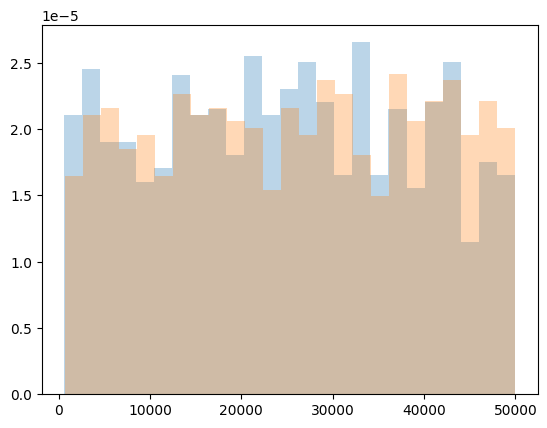

In [24]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'Physical_activity'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'Physical_activity'],density=True,bins=25,alpha=0.3)

/tmp/ipykernel_28775/3653644677.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


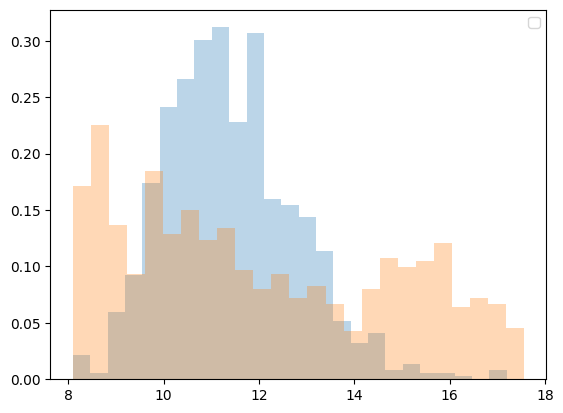

In [25]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'Level_of_Hemoglobin'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'Level_of_Hemoglobin'],density=True,bins=25,alpha=0.3)
plt.legend()

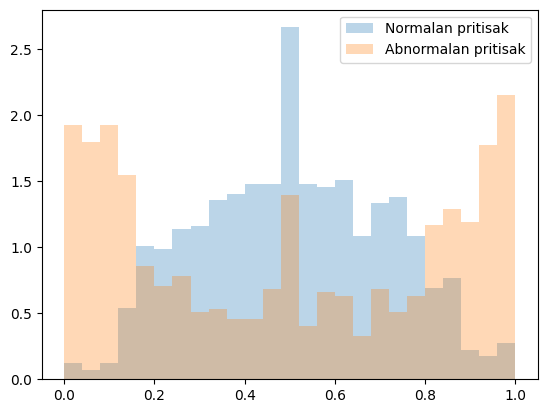

In [26]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'Genetic_Pedigree_Coefficient'],density=True,bins=25,alpha=0.3,label='Normalan pritisak')
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'Genetic_Pedigree_Coefficient'],density=True,bins=25,alpha=0.3,label='Abnormalan pritisak')
plt.legend()

(array([0.02799552, 0.02177429, 0.01466432, 0.02532928, 0.01421995,
        0.01644181, 0.01421995, 0.02221867, 0.01288683, 0.01599744,
        0.02132992, 0.01555307, 0.01733056, 0.01821931, 0.02044117,
        0.01377557, 0.01155371, 0.01955243, 0.01288683, 0.01022059,
        0.01288683, 0.02444053, 0.01733056, 0.01688619, 0.02044117]),
 array([18.  , 20.28, 22.56, 24.84, 27.12, 29.4 , 31.68, 33.96, 36.24,
        38.52, 40.8 , 43.08, 45.36, 47.64, 49.92, 52.2 , 54.48, 56.76,
        59.04, 61.32, 63.6 , 65.88, 68.16, 70.44, 72.72, 75.  ]),
 <BarContainer object of 25 artists>)

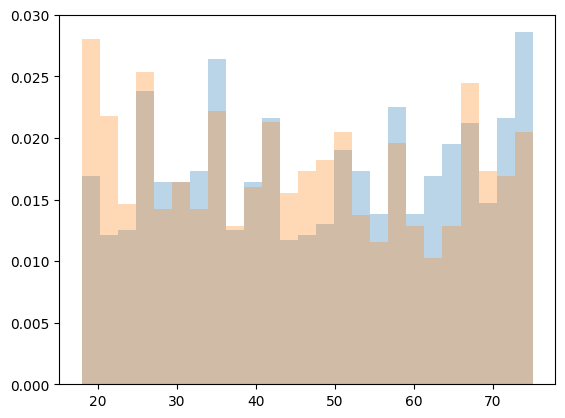

In [27]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'Age'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'Age'],density=True,bins=25,alpha=0.3)

(array([0.03102837, 0.01646403, 0.01519757, 0.02596251, 0.01203141,
        0.0316616 , 0.03926039, 0.0177305 , 0.02406282, 0.01266464,
        0.03609422, 0.03736069, 0.01709726, 0.02342958, 0.01076494,
        0.03672746, 0.02406282, 0.02089666, 0.0335613 , 0.02089666,
        0.03419453, 0.02912867, 0.0139311 , 0.02659574, 0.03419453]),
 array([10. , 11.6, 13.2, 14.8, 16.4, 18. , 19.6, 21.2, 22.8, 24.4, 26. ,
        27.6, 29.2, 30.8, 32.4, 34. , 35.6, 37.2, 38.8, 40.4, 42. , 43.6,
        45.2, 46.8, 48.4, 50. ]),
 <BarContainer object of 25 artists>)

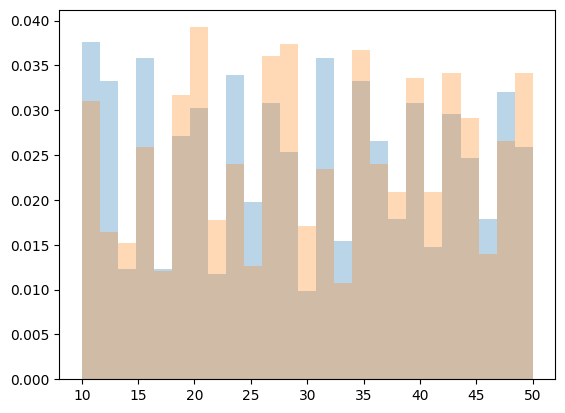

In [28]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'BMI'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'BMI'],density=True,bins=25,alpha=0.3)

(array([2.23201223e-05, 1.77546428e-05, 1.77546428e-05, 1.87691938e-05,
        2.18128468e-05, 1.62328162e-05, 2.07982958e-05, 2.33346734e-05,
        1.97837448e-05, 1.87691938e-05, 1.72473673e-05, 2.28273978e-05,
        2.28273978e-05, 1.77546428e-05, 2.02910203e-05, 2.02910203e-05,
        2.18128468e-05, 2.13055713e-05, 2.33346734e-05, 1.87691938e-05,
        1.97837448e-05, 1.42037142e-05, 1.92764693e-05, 2.28273978e-05,
        2.07982958e-05]),
 array([4.400000e+01, 2.041280e+03, 4.038560e+03, 6.035840e+03,
        8.033120e+03, 1.003040e+04, 1.202768e+04, 1.402496e+04,
        1.602224e+04, 1.801952e+04, 2.001680e+04, 2.201408e+04,
        2.401136e+04, 2.600864e+04, 2.800592e+04, 3.000320e+04,
        3.200048e+04, 3.399776e+04, 3.599504e+04, 3.799232e+04,
        3.998960e+04, 4.198688e+04, 4.398416e+04, 4.598144e+04,
        4.797872e+04, 4.997600e+04]),
 <BarContainer object of 25 artists>)

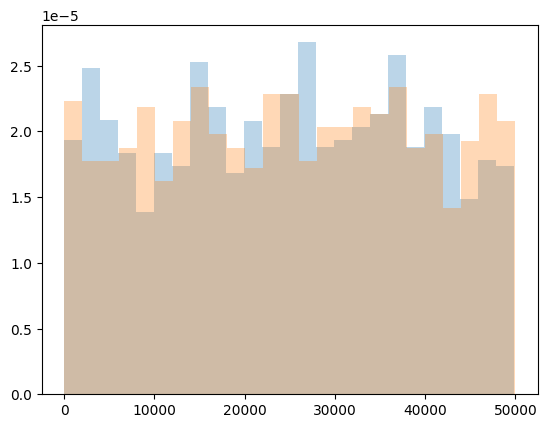

In [29]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'salt_content_in_the_diet'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'salt_content_in_the_diet'],density=True,bins=25,alpha=0.3)

(array([0.00883225, 0.00172584, 0.00137052, 0.00131976, 0.00218268,
        0.00167508, 0.00157356, 0.00182736, 0.00197964, 0.00213192,
        0.00197964, 0.00147204, 0.00121824, 0.00137052, 0.00162432,
        0.0017766 , 0.00147204, 0.0017766 , 0.0017766 , 0.00187812,
        0.00162432, 0.00218268, 0.00172584, 0.00187812, 0.00172584]),
 array([  0.  ,  19.96,  39.92,  59.88,  79.84,  99.8 , 119.76, 139.72,
        159.68, 179.64, 199.6 , 219.56, 239.52, 259.48, 279.44, 299.4 ,
        319.36, 339.32, 359.28, 379.24, 399.2 , 419.16, 439.12, 459.08,
        479.04, 499.  ]),
 <BarContainer object of 25 artists>)

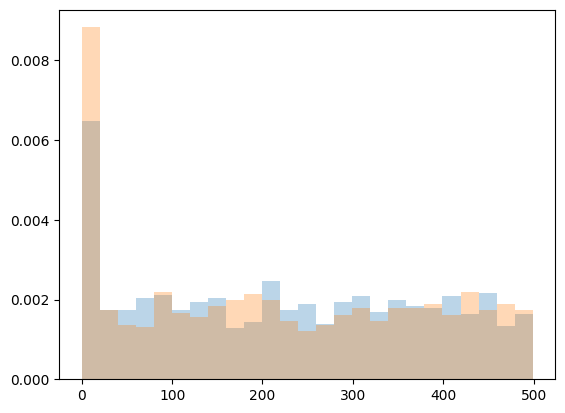

In [30]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'alcohol_consumption_per_day'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'alcohol_consumption_per_day'],density=True,bins=25,alpha=0.3)

(array([0.02799552, 0.02177429, 0.01466432, 0.02532928, 0.01421995,
        0.01644181, 0.01421995, 0.02221867, 0.01288683, 0.01599744,
        0.02132992, 0.01555307, 0.01733056, 0.01821931, 0.02044117,
        0.01377557, 0.01155371, 0.01955243, 0.01288683, 0.01022059,
        0.01288683, 0.02444053, 0.01733056, 0.01688619, 0.02044117]),
 array([18.  , 20.28, 22.56, 24.84, 27.12, 29.4 , 31.68, 33.96, 36.24,
        38.52, 40.8 , 43.08, 45.36, 47.64, 49.92, 52.2 , 54.48, 56.76,
        59.04, 61.32, 63.6 , 65.88, 68.16, 70.44, 72.72, 75.  ]),
 <BarContainer object of 25 artists>)

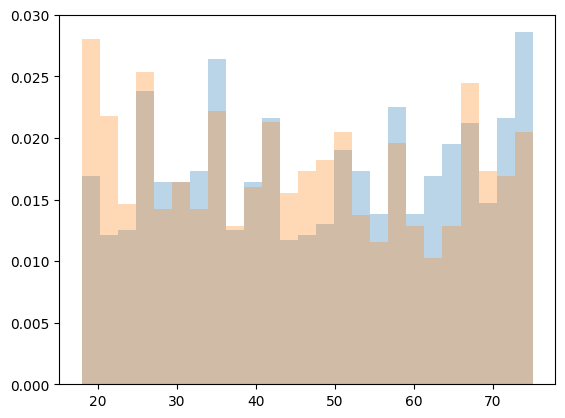

In [31]:
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==0,'Age'],density=True,bins=25,alpha=0.3)
plt.hist(df.loc[df['Blood_Pressure_Abnormality']==1,'Age'],density=True,bins=25,alpha=0.3)

##Kategoricka obiljezja

In [32]:
pd.crosstab(df['Blood_Pressure_Abnormality'],df['Sex']).style.background_gradient(cmap='summer_r')

Sex,0,1
Blood_Pressure_Abnormality,,
0,538,475
1,470,517


<Axes: xlabel='Blood_Pressure_Abnormality', ylabel='count'>

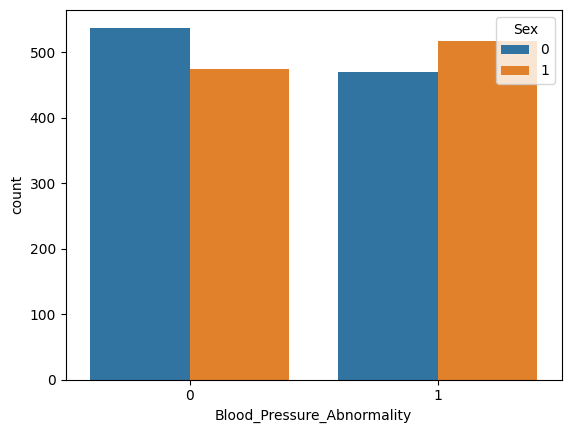

In [33]:
sns.countplot(x='Blood_Pressure_Abnormality',hue='Sex',data=df)

In [34]:
pd.crosstab(df['Blood_Pressure_Abnormality'],df['Smoking']).style.background_gradient(cmap='summer_r')

Smoking,0,1
Blood_Pressure_Abnormality,,
0,503,510
1,478,509


<Axes: xlabel='Blood_Pressure_Abnormality', ylabel='count'>

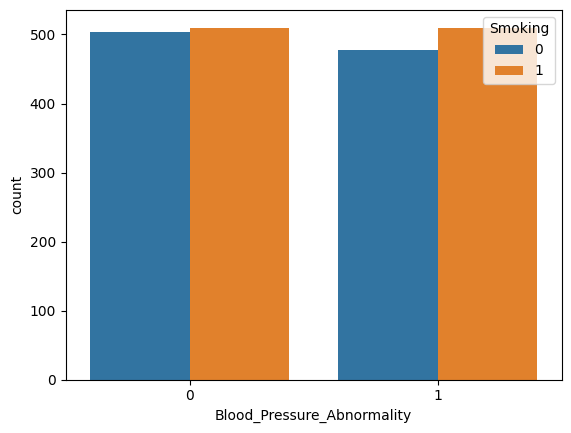

In [35]:
sns.countplot(x='Blood_Pressure_Abnormality',hue='Smoking',data=df)

In [36]:
pd.crosstab(df['Blood_Pressure_Abnormality'],df['Chronic_kidney_disease']).style.background_gradient(cmap='summer_r')

Chronic_kidney_disease,0,1
Blood_Pressure_Abnormality,,
0,716,297
1,274,713


<Axes: xlabel='Blood_Pressure_Abnormality', ylabel='count'>

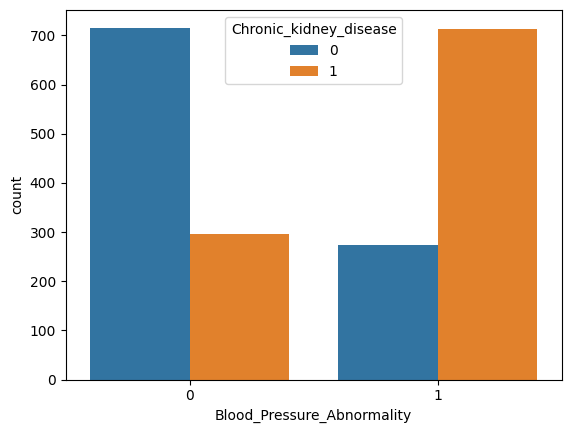

In [37]:
sns.countplot(x='Blood_Pressure_Abnormality',hue='Chronic_kidney_disease',data=df)

In [38]:
pd.crosstab(df['Blood_Pressure_Abnormality'],df['Adrenal_and_thyroid_disorders']).style.background_gradient(cmap='summer_r')

Adrenal_and_thyroid_disorders,0,1
Blood_Pressure_Abnormality,,
0,722,291
1,391,596


<Axes: xlabel='Blood_Pressure_Abnormality', ylabel='count'>

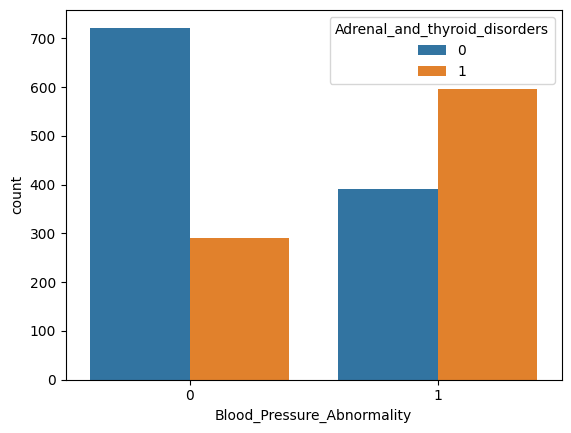

In [39]:
sns.countplot(x='Blood_Pressure_Abnormality',hue='Adrenal_and_thyroid_disorders',data=df)

In [40]:
pd.crosstab(df['Blood_Pressure_Abnormality'],df['Level_of_Stress']).style.background_gradient(cmap='summer_r')

Level_of_Stress,1,2,3
Blood_Pressure_Abnormality,,,
0,339,330,344
1,327,313,347


<Axes: xlabel='Blood_Pressure_Abnormality', ylabel='count'>

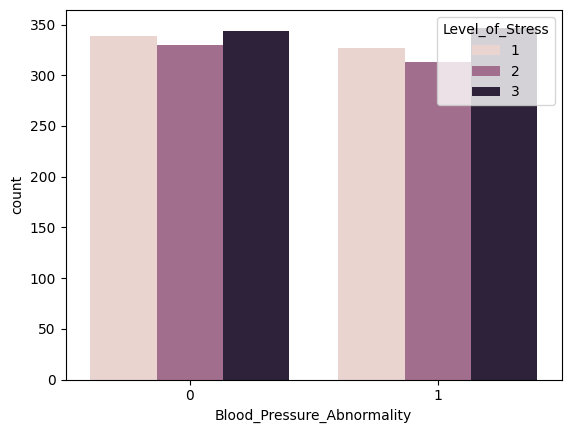

In [41]:
sns.countplot(x='Blood_Pressure_Abnormality',hue='Level_of_Stress',data=df)

#Obuka i formiranje modela

##Podjela skupa podataka na trening (90%) i test (10%) skup

In [19]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1,random_state=10,stratify=y)

##Standardizacija

In [21]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()
s.fit(x_train)
x_train_std = s.transform(x_train)
x_test_std = s.transform(x_test)
x_train_std = pd.DataFrame(x_train_std)
x_test_std = pd.DataFrame(x_test_std)
x_train_std.columns = list(x.columns)
x_test_std.columns = list(x.columns)

##Obuka modela na trening skupu, a testiranje na test skupu

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

###kNN

####Bez standardizacije

In [26]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': range(1,31), 'metric':('hamming', 'euclidean', 'manhattan','chebyshev')}
classifier_knn = KNeighborsClassifier()
clf = GridSearchCV(KNeighborsClassifier(), parameters, scoring='recall', cv=10, verbose=3)
clf.fit(x_train, y_train)

Fitting 10 folds for each of 120 candidates, totalling 1200 fits
[CV 1/10] END ....metric=hamming, n_neighbors=1;, score=0.640 total time=   0.1s
[CV 2/10] END ....metric=hamming, n_neighbors=1;, score=0.685 total time=   0.1s
[CV 3/10] END ....metric=hamming, n_neighbors=1;, score=0.573 total time=   0.1s
[CV 4/10] END ....metric=hamming, n_neighbors=1;, score=0.584 total time=   0.1s
[CV 5/10] END ....metric=hamming, n_neighbors=1;, score=0.618 total time=   0.1s
[CV 6/10] END ....metric=hamming, n_neighbors=1;, score=0.584 total time=   0.1s
[CV 7/10] END ....metric=hamming, n_neighbors=1;, score=0.652 total time=   0.1s
[CV 8/10] END ....metric=hamming, n_neighbors=1;, score=0.629 total time=   0.1s
[CV 9/10] END ....metric=hamming, n_neighbors=1;, score=0.602 total time=   0.1s
[CV 10/10] END ...metric=hamming, n_neighbors=1;, score=0.636 total time=   0.1s
[CV 1/10] END ....metric=hamming, n_neighbors=2;, score=0.472 total time=   0.1s
[CV 2/10] END ....metric=hamming, n_neighbor

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'metric': ('hamming', 'euclidean', 'manhattan',
                                    'chebyshev'),
                         'n_neighbors': range(1, 31)},
             scoring='recall', verbose=3)

In [27]:
print("Najbolji skor: ", clf.best_score_)
print("Najbolji hiperparametri: ", clf.best_params_)

Najbolji skor:  0.7309627170582227
Najbolji hiperparametri:  {'metric': 'hamming', 'n_neighbors': 29}


####Sa standardizacijom

In [28]:
parameters = {'n_neighbors': range(1,31), 'metric':('hamming', 'euclidean', 'manhattan','chebyshev')}
clf = GridSearchCV(KNeighborsClassifier(), parameters, scoring='recall', cv=10, verbose=3)
clf.fit(x_train_std, y_train)

Fitting 10 folds for each of 120 candidates, totalling 1200 fits
[CV 1/10] END ....metric=hamming, n_neighbors=1;, score=0.640 total time=   0.0s
[CV 2/10] END ....metric=hamming, n_neighbors=1;, score=0.663 total time=   0.0s
[CV 3/10] END ....metric=hamming, n_neighbors=1;, score=0.618 total time=   0.0s
[CV 4/10] END ....metric=hamming, n_neighbors=1;, score=0.573 total time=   0.0s
[CV 5/10] END ....metric=hamming, n_neighbors=1;, score=0.629 total time=   0.0s
[CV 6/10] END ....metric=hamming, n_neighbors=1;, score=0.573 total time=   0.0s
[CV 7/10] END ....metric=hamming, n_neighbors=1;, score=0.562 total time=   0.0s
[CV 8/10] END ....metric=hamming, n_neighbors=1;, score=0.663 total time=   0.0s
[CV 9/10] END ....metric=hamming, n_neighbors=1;, score=0.625 total time=   0.0s
[CV 10/10] END ...metric=hamming, n_neighbors=1;, score=0.580 total time=   0.0s
[CV 1/10] END ....metric=hamming, n_neighbors=2;, score=0.427 total time=   0.0s
[CV 2/10] END ....metric=hamming, n_neighbor

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'metric': ('hamming', 'euclidean', 'manhattan',
                                    'chebyshev'),
                         'n_neighbors': range(1, 31)},
             scoring='recall', verbose=3)

In [29]:
print("Najbolji skor: ", clf.best_score_)
print("Najbolji hiperparametri: ", clf.best_params_)

Najbolji skor:  0.7444713993871298
Najbolji hiperparametri:  {'metric': 'hamming', 'n_neighbors': 29}


In [23]:
# Obuka na std trening skupu
classifier_knn_std = KNeighborsClassifier(n_neighbors=29, metric='hamming')
classifier_knn_std.fit(x_train_std,y_train)

# Testiranje na std test skupu
y_pred = classifier_knn_std.predict(x_test_std)

In [24]:
from sklearn import metrics
precision = metrics.precision_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
sensitivity = metrics.recall_score(y_test, y_pred)
f_score = metrics.f1_score(y_test, y_pred)

print('Precision: ', precision)
print('Accuracy: ', accuracy)
print('Sensitivity/Recall: ', sensitivity)
print('F score: ', f_score)

Precision:  0.72
Accuracy:  0.725
Sensitivity/Recall:  0.7272727272727273
F score:  0.7236180904522613


In [25]:
conf_mat_knn_std = confusion_matrix(y_test, y_pred, labels=classifier_knn_std.classes_)

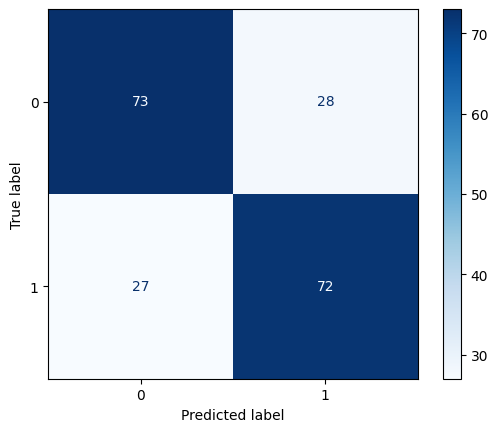

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat_knn_std,  display_labels=classifier_knn_std.classes_)
disp.plot(cmap="Blues")

###SVM (Masina na bazi vektora nosaca)

In [27]:
from sklearn.svm import SVC

####Bez standardizacije

In [ ]:
from sklearn.model_selection import cross_val_score

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in kernels:
    model = SVC(kernel=kernel, C=1)

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(kernel,":", scores.mean())

linear : 0.5732368437757887
rbf : 0.29843839268710726
poly : 0.25338665650987113
sigmoid : 0.4819843839268711


In [ ]:
vrijednosti_C = [0.1, 1, 5, 10]

for c in vrijednosti_C:
    model = SVC(kernel='linear', C=c)

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(c, ":", scores.mean())

0.1 : 0.6037262743604394
1 : 0.5732368437757887
5 : 0.5822192598235256
10 : 0.5981590808100045


In [47]:
classifier_svm = SVC(
    kernel='linear',
    C=0.1
)

classifier_svm.fit(x_train, y_train)

y_pred = classifier_svm.predict(x_test)

In [48]:
from sklearn import metrics
precision = metrics.precision_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
sensitivity = metrics.recall_score(y_test, y_pred)
f_score = metrics.f1_score(y_test, y_pred)

print('Precision: ', precision)
print('Accuracy: ', accuracy)
print('Sensitivity/Recall: ', sensitivity)
print('F score: ', f_score)

Precision:  0.6122448979591837
Accuracy:  0.615
Sensitivity/Recall:  0.6060606060606061
F score:  0.6091370558375635


####Sa standardizacijom

In [49]:
from sklearn.model_selection import cross_val_score

kernels = ['linear', 'rbf','sigmoid']

for kernel in kernels:
    model = SVC(kernel=kernel, C=1)

    scores = cross_val_score(
        model,
        x_train_std,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(kernel,":", scores.mean())

linear : 0.7264711483526949
rbf : 0.8626610804291246
sigmoid : 0.7039040182822319


In [51]:
vrijednosti_C = [0.1, 1, 5, 10]

for c in vrijednosti_C:
    model = SVC(kernel='rbf', C=c)

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(c, ":", scores.mean())

0.1 : 0.24656255951247377
1 : 0.29843839268710726
5 : 0.29511204215070147
10 : 0.30973147971814885


In [28]:
classifier_svm_std = SVC(
    kernel='rbf',
    C=10
)

classifier_svm_std.fit(x_train_std, y_train)

y_pred = classifier_svm_std.predict(x_test_std)

In [29]:
from sklearn import metrics
precision = metrics.precision_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
sensitivity = metrics.recall_score(y_test, y_pred)
f_score = metrics.f1_score(y_test, y_pred)

print('Precision: ', precision)
print('Accuracy: ', accuracy)
print('Sensitivity/Recall: ', sensitivity)
print('F score: ', f_score)

Precision:  0.8431372549019608
Accuracy:  0.855
Sensitivity/Recall:  0.8686868686868687
F score:  0.8557213930348259


In [30]:
conf_mat_svm_std = confusion_matrix(y_test, y_pred, labels=classifier_svm_std.classes_)

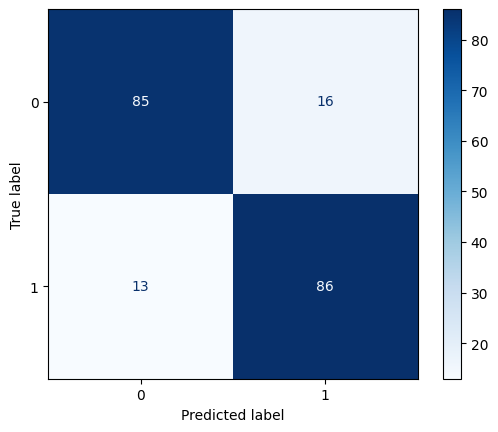

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat_svm_std,  display_labels=classifier_svm_std.classes_)
disp.plot(cmap="Blues")

###Random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

####Bez standardizacije

In [57]:
n_values = [50, 100, 200]

for n in n_values:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(n, ":", scores.mean())

50 : 0.8964260775725258
100 : 0.8941725385640831
200 : 0.898666920586555


In [58]:
depth_values = [5, 10, 20, None]

for depth in depth_values:

    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(depth, ":", scores.mean())

5 : 0.8615501809179203
10 : 0.9009585475782391
20 : 0.8975496730781438
None : 0.8964260775725258


In [46]:
classifier_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

classifier_rf.fit(x_train, y_train)

y_pred = classifier_rf.predict(x_test)

In [47]:
from sklearn import metrics
precision = metrics.precision_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
sensitivity = metrics.recall_score(y_test, y_pred)
f_score = metrics.f1_score(y_test, y_pred)

print('Precision: ', precision)
print('Accuracy: ', accuracy)
print('Sensitivity/Recall: ', sensitivity)
print('F score: ', f_score)

Precision:  0.9081632653061225
Accuracy:  0.905
Sensitivity/Recall:  0.898989898989899
F score:  0.9035532994923858


####Sa standardizacijom

In [61]:
n_values = [50, 100, 200]

for n in n_values:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        x_train_std,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(n, ":", scores.mean())

50 : 0.89417888656129
100 : 0.8930489430584652
200 : 0.8997968640893799


In [62]:
depth_values = [5, 10, 20, None]

for depth in depth_values:

    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        x_train_std,
        y_train,
        cv=5,
        scoring='recall'
    )

    print(depth, ":", scores.mean())

5 : 0.8615501809179203
10 : 0.8998286040754143
20 : 0.8964260775725258
None : 0.89417888656129


In [48]:
classifier_rf_std = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

classifier_rf_std.fit(x_train_std, y_train)

y_pred = classifier_rf_std.predict(x_test_std)

In [49]:
from sklearn import metrics
precision = metrics.precision_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
sensitivity = metrics.recall_score(y_test, y_pred)
f_score = metrics.f1_score(y_test, y_pred)

print('Precision: ', precision)
print('Accuracy: ', accuracy)
print('Sensitivity/Recall: ', sensitivity)
print('F score: ', f_score)

Precision:  0.9081632653061225
Accuracy:  0.905
Sensitivity/Recall:  0.898989898989899
F score:  0.9035532994923858


In [50]:
conf_mat_rf = confusion_matrix(y_test, y_pred, labels=classifier_rf.classes_)

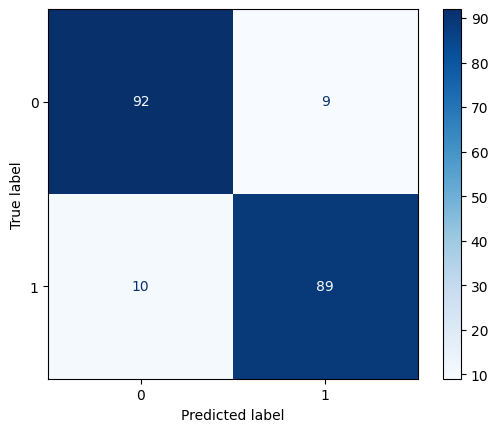

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat_rf,  display_labels=classifier_rf.classes_)
disp.plot(cmap="Blues")

####Doprinos svakog obiljezja modelu

In [56]:
feature_names = [
    'Level_of_Hemoglobin',
    'Genetic_Pedigree_Coefficient',
    'Age',
    'BMI',
    'Sex',
    'Smoking',
    'Physical_activity',
    'salt_content_in_the_diet',
    'alcohol_consumption_per_day',
    'Level_of_Stress',
    'Chronic_kidney_disease',
    'Adrenal_and_thyroid_disorders'
]

for feature, importance in zip(feature_names, classifier_rf.feature_importances_):
    print(feature, ":", importance)

Level_of_Hemoglobin : 0.2385622357753567
Genetic_Pedigree_Coefficient : 0.2860662285977135
Age : 0.04223266432547369
BMI : 0.03736234705739241
Sex : 0.019857122099624102
Smoking : 0.00646152209878771
Physical_activity : 0.04754033825139302
salt_content_in_the_diet : 0.044471757612573125
alcohol_consumption_per_day : 0.04042312989642273
Level_of_Stress : 0.010560227146212908
Chronic_kidney_disease : 0.15870862949210274
Adrenal_and_thyroid_disorders : 0.06775379764694746


####Graf

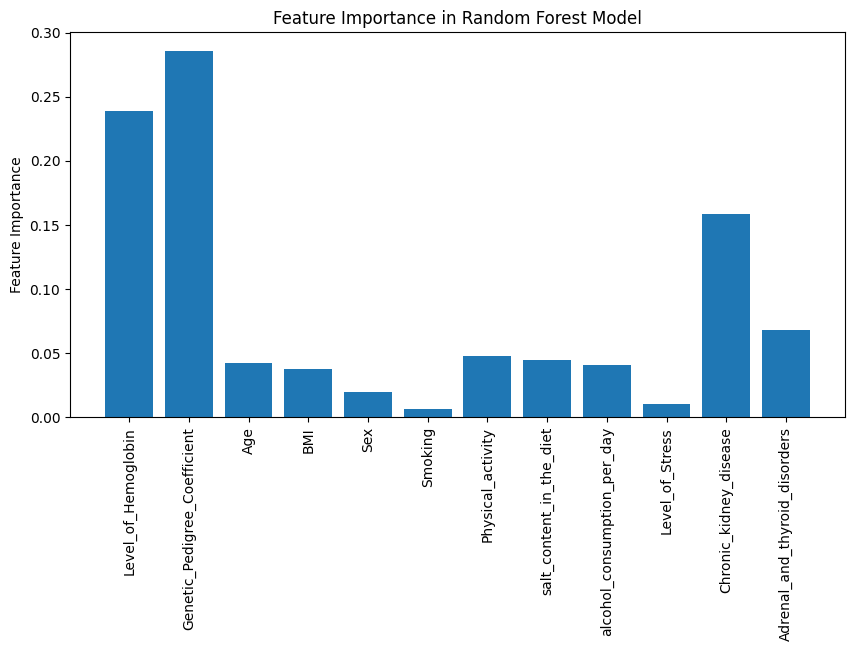

In [57]:
import matplotlib.pyplot as plt

features = feature_names
importance = classifier_rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=90)
plt.ylabel("Feature Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

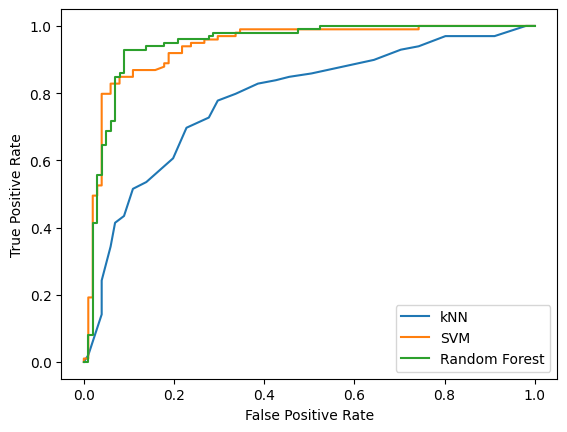

In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probability predictions
y_prob_knn = classifier_knn_std.predict_proba(x_test_std)[:,1]
y_prob_rf = classifier_rf.predict_proba(x_test)[:,1]

# za SVM mora probability=True
classifier_svm_std = SVC(kernel='rbf', C=10, probability=True)
classifier_svm_std.fit(x_train_std, y_train)

y_prob_svm = classifier_svm_std.predict_proba(x_test_std)[:,1]

# ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_knn, tpr_knn, label="kNN")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

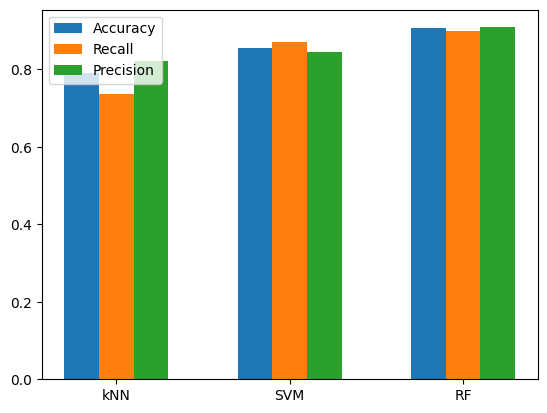

In [55]:
import matplotlib.pyplot as plt
import numpy as np

models = ['kNN', 'SVM', 'RF']
accuracy = [0.79, 0.855, 0.905]
recall = [0.737, 0.869, 0.899]
precision = [0.82, 0.843, 0.908]

x = np.arange(len(models))

plt.bar(x-0.2, accuracy, width=0.2, label='Accuracy')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x+0.2, precision, width=0.2, label='Precision')

plt.xticks(x, models)
plt.legend()
plt.show()

#Rezultati

RECALL
kNN: 0.72
SVM: 0.86
RF: 0.89